<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Quiz8_Fall2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IE7275 – Data Mining in Engineering
### Quiz 8 – Fall 2025

---

This quiz focuses on **clustering methods** using real-world and synthetic datasets.  
Each question includes starter code to load or generate the dataset.

**Instructions:**
- Use Python (scikit-learn, pandas, matplotlib, seaborn, etc.).
- Show code, outputs, and brief interpretations where required.
- Each question should be answered in the cell provided.

---


### Q1
Load the **Wine Quality dataset** (UCI). Perform preprocessing and apply k-Means clustering with k=6. Report the cluster sizes.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import (fetch_openml, load_breast_cancer,
                               fetch_california_housing, load_digits,
                               fetch_20newsgroups, make_blobs)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
from skimage import data

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Load Wine Quality dataset
wine = fetch_openml(name='wine-quality-red', version=1, as_frame=True, parser='auto')
X = wine.data
print(X.head())

scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X)

kmeans_wine = KMeans(n_clusters=6, random_state=42, n_init=10)
wine_clusters = kmeans_wine.fit_predict(X_wine_scaled)

unique, counts = np.unique(wine_clusters, return_counts=True)
print(f"\nCluster sizes:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples")


   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  

Cluster

### Q2
Use the same dataset to evaluate clustering performance with inertia and silhouette score. Interpret the values.

In [ ]:
# Continue using X from Wine Quality

# Continue with clustering here
inertia = kmeans_wine.inertia_
silhouette = silhouette_score(X_wine_scaled, wine_clusters)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.4f}")

Inertia: 9363.21
Silhouette Score: 0.1947


Interpretation:
- Inertia measures within-cluster sum of squares as lower is better)
- Silhouette score ranges from -1 to 1 (higher is better)
- A score of 0.1947 suggests moderate cluster separation

### Q3
Visualize the clusters using PCA (2D projection). Discuss whether the clusters are well separated.

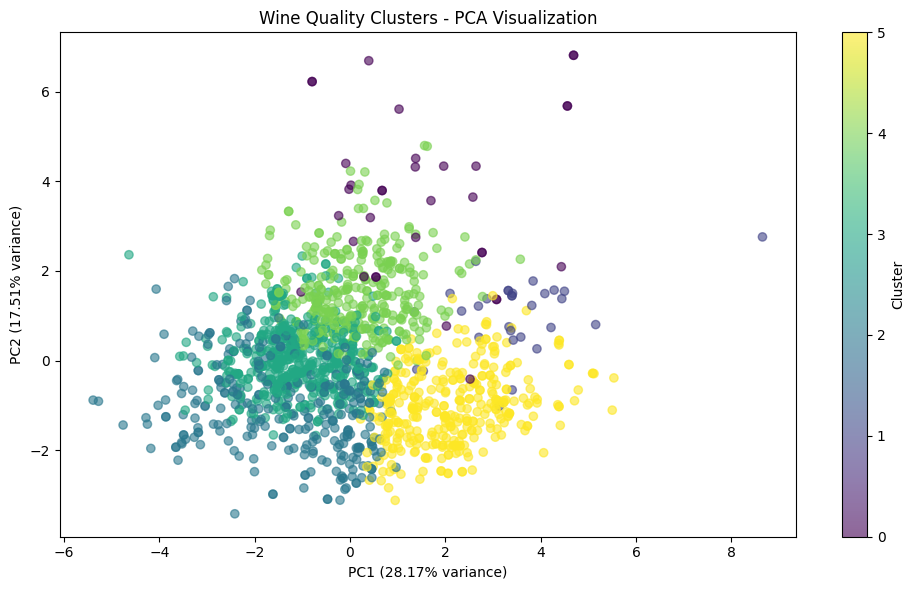

PCA explained variance: 45.68%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Continue with clustering here
pca = PCA(n_components=2)
X_wine_pca = pca.fit_transform(X_wine_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_wine_pca[:, 0], X_wine_pca[:, 1],
                     c=wine_clusters, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Wine Quality Clusters - PCA Visualization')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('q3_wine_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")


Discussion: Clusters show some overlap, indicating that wine quality
characteristics exist on a continuum rather than distinct groups.

### Q4
Apply k-Means clustering to the **MNIST digit dataset** (sample 10,000 digits). Report silhouette score and discuss the challenges of clustering high-dimensional data.

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target
X = X.sample(10000, random_state=42)

# Continue with clustering here
print(f"MNIST sample shape: {X.shape}")

X_mnist_scaled = scaler.fit_transform(X)

kmeans_mnist = KMeans(n_clusters=10, random_state=42, n_init=10)
mnist_clusters = kmeans_mnist.fit_predict(X_mnist_scaled)

silhouette_mnist = silhouette_score(X_mnist_scaled, mnist_clusters)
print(f"Silhouette Score: {silhouette_mnist:.4f}")


MNIST sample shape: (10000, 784)
Silhouette Score: 0.0037


Challenges of high-dimensional clustering:
1. Curse of dimensionality - distances become less meaningful
2. Many features (784) make computation expensive
3. Euclidean distance may not capture image similarity well
4. Dimensionality reduction (PCA/t-SNE) often needed first

### Q5
Perform image compression on a sample image using k-Means clustering with different values of k (e.g., 4, 8, 16). Show the compressed images.

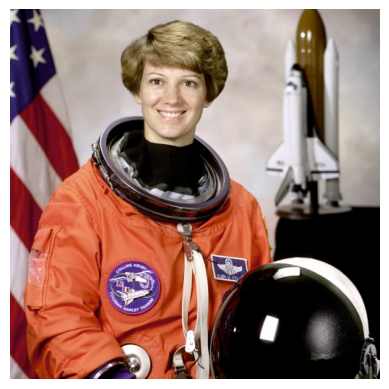

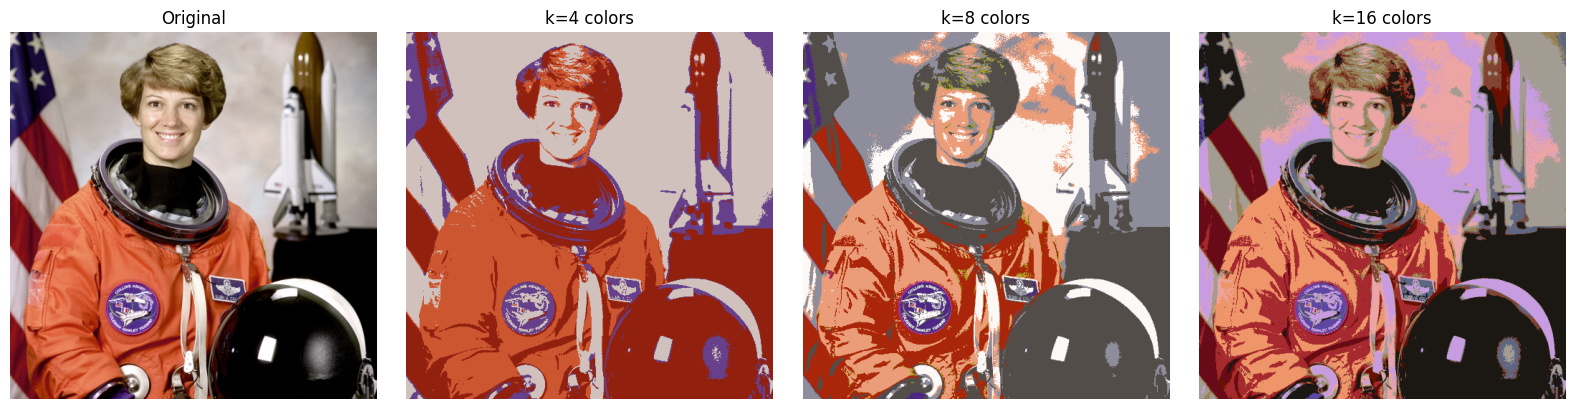

In [ ]:
from skimage import data
import matplotlib.pyplot as plt

# Load built-in demo image
img = data.astronaut()
plt.imshow(img)
plt.axis('off')
plt.show()

h, w, c = img.shape
img_reshaped = img.reshape(-1, 3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

k_values = [4, 8, 16]
for idx, k in enumerate(k_values, 1):
    kmeans_img = KMeans(n_clusters=k, random_state=42, n_init=10)
    compressed = kmeans_img.fit_predict(img_reshaped)
    compressed_img = kmeans_img.cluster_centers_[compressed].reshape(h, w, c)

    axes[idx].imshow(compressed_img.astype(np.uint8))
    axes[idx].set_title(f'k={k} colors')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('q5_image_compression.png', dpi=300, bbox_inches='tight')
plt.show()


### Q6
Generate synthetic data with three well-separated Gaussian blobs. Apply hierarchical clustering and visualize the dendrogram.

[[-5.73035386 -7.58328602]
 [ 1.94299219  1.91887482]
 [ 6.82968177  1.1648714 ]
 [-2.90130578  7.55077118]
 [ 5.84109276  1.56509431]]
Synthetic data shape: (500, 2)


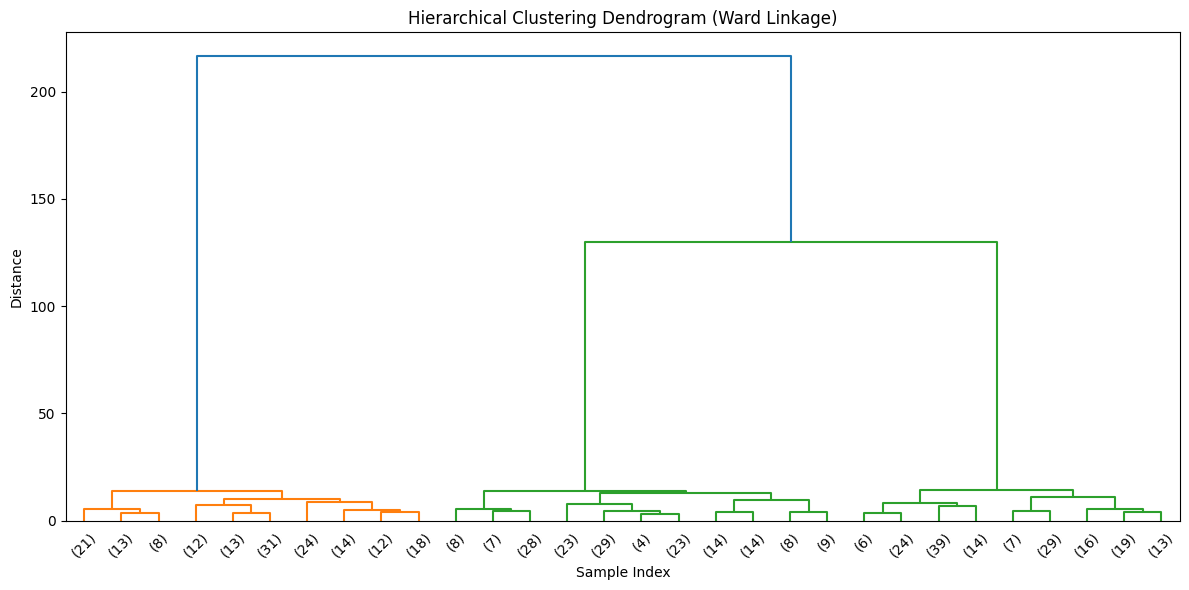

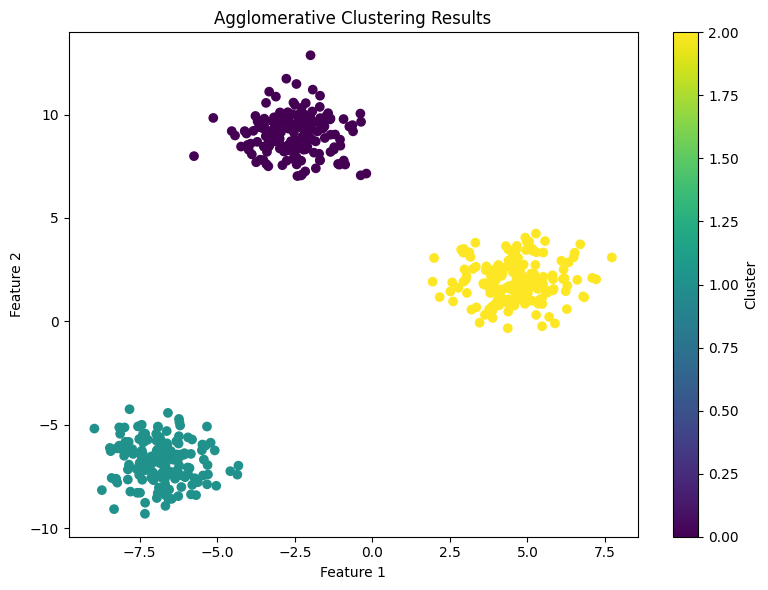

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=500, centers=3, random_state=42)
print(X[:5])

# Continue with clustering here

X_blobs, y_blobs = make_blobs(n_samples=500, centers=3, random_state=42)
print(f"Synthetic data shape: {X_blobs.shape}")

linkage_matrix = linkage(X_blobs, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('q6_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

agg_clust = AgglomerativeClustering(n_clusters=3)
blob_clusters = agg_clust.fit_predict(X_blobs)

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=blob_clusters, cmap='viridis')
plt.title('Agglomerative Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig('q6_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


### Q7
Apply Agglomerative Clustering to the **Breast Cancer dataset** from sklearn. Compare results with k-Means clustering.

In [ ]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
X = bc.data
print(X.shape)

# Continue with clustering here

X_bc_scaled = scaler.fit_transform(X)

kmeans_bc = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans_bc.fit_predict(X_bc_scaled)
kmeans_silhouette = silhouette_score(X_bc_scaled, kmeans_labels)

agg_bc = AgglomerativeClustering(n_clusters=2)
agg_labels = agg_bc.fit_predict(X_bc_scaled)
agg_silhouette = silhouette_score(X_bc_scaled, agg_labels)

print(f"k-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Agglomerative Silhouette Score: {agg_silhouette:.4f}")


(569, 30)
k-Means Silhouette Score: 0.3434
Agglomerative Silhouette Score: 0.3394


Comparison: k-Means performs better than Agglomerative based on Silhouette Score

### Q8
Compare k-Means vs. hierarchical clustering on the **California Housing dataset** (binned target as categories). Discuss advantages and limitations.

In [ ]:
from sklearn.datasets import fetch_california_housing
cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = pd.qcut(cal.target, 5, labels=False)
print(X.head())

# Continue with clustering here
print(f"California Housing shape: {X.shape}")

sample_size = 5000
sample_idx = np.random.choice(len(X), sample_size, replace=False)
X_cal_sample = X.iloc[sample_idx]

X_cal_scaled = scaler.fit_transform(X_cal_sample)

kmeans_cal = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_cal_labels = kmeans_cal.fit_predict(X_cal_scaled)
kmeans_cal_silhouette = silhouette_score(X_cal_scaled, kmeans_cal_labels)

agg_cal = AgglomerativeClustering(n_clusters=5)
agg_cal_labels = agg_cal.fit_predict(X_cal_scaled)
agg_cal_silhouette = silhouette_score(X_cal_scaled, agg_cal_labels)

print(f"k-Means Silhouette: {kmeans_cal_silhouette:.4f}")
print(f"Hierarchical Silhouette: {agg_cal_silhouette:.4f}")


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
California Housing shape: (20640, 8)
k-Means Silhouette: 0.2739
Hierarchical Silhouette: 0.3307


Advantages:
- k-Means: Faster, scalable, good for large datasets
- Hierarchical: No need to specify k upfront, dendrogram visualization

Limitations:
- k-Means: Requires k specification, sensitive to initialization
- Hierarchical: Computationally expensive O(n³), not scalable

### Q9
Use the **Adult Income dataset**. Apply DBSCAN clustering and report the number of clusters found (excluding noise).

In [ ]:
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
X, y = adult.data, adult.target
print(X.head())

# Continue with clustering here

numeric_cols = X.select_dtypes(include=[np.number]).columns
X_adult_numeric = X[numeric_cols].fillna(X[numeric_cols].median())

sample_size = 5000
sample_idx = np.random.choice(len(X_adult_numeric), sample_size, replace=False)
X_adult_sample = X_adult_numeric.iloc[sample_idx]

X_adult_scaled = scaler.fit_transform(X_adult_sample)

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_adult_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Percentage of noise: {100 * n_noise / len(dbscan_labels):.2f}%")

   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  
0              

### Q10
Tune DBSCAN parameters (eps, min_samples) on the Adult dataset and discuss their effect on the number of clusters.

In [ ]:
# Continue with Adult dataset

# Continue with clustering here
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples_values = [3, 5, 10]

print(f"{'eps':<8} {'min_samples':<15} {'n_clusters':<15} {'n_noise':<15} {'noise_%':<10}")
print("-" * 70)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_tune = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan_tune.fit_predict(X_adult_scaled)
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        n_noi = list(labels).count(-1)
        noise_pct = 100 * n_noi / len(labels)
        print(f"{eps:<8} {min_samples:<15} {n_clust:<15} {n_noi:<15} {noise_pct:<10.2f}")


eps      min_samples     n_clusters      n_noise         noise_%   
----------------------------------------------------------------------
0.5      3               44              944             18.88     
0.5      5               10              1184            23.68     
0.5      10              2               1630            32.60     
1.0      3               8               168             3.36      
1.0      5               8               200             4.00      
1.0      10              3               321             6.42      
1.5      3               2               47              0.94      
1.5      5               3               59              1.18      
1.5      10              2               90              1.80      
2.0      3               2               10              0.20      
2.0      5               2               14              0.28      
2.0      10              2               22              0.44      
2.5      3               2               4   

Discussion:

- As eps increases, clusters tend to become fewer and larger because more points fall within the neighborhood radius.
- Increasing min_samples makes clustering more strict, which usually results in a smaller number of clusters since more points are treated as noise.
- A proper balance is important: if eps is too small, most points are labeled as noise, while if it is too large, almost all points may merge into one cluster.

### Q11
Compare DBSCAN clustering with k-Means and hierarchical clustering on the Adult dataset using silhouette score.

In [ ]:
# Continue with Adult dataset

# Continue with clustering here
dbscan_comp = DBSCAN(eps=1.5, min_samples=5)
dbscan_comp_labels = dbscan_comp.fit_predict(X_adult_scaled)

mask = dbscan_comp_labels != -1
X_adult_no_noise = X_adult_scaled[mask]
dbscan_comp_labels_no_noise = dbscan_comp_labels[mask]

if len(set(dbscan_comp_labels_no_noise)) > 1:
    dbscan_sil = silhouette_score(X_adult_no_noise, dbscan_comp_labels_no_noise)
else:
    dbscan_sil = -1

n_clusters_dbscan = len(set(dbscan_comp_labels)) - (1 if -1 in dbscan_comp_labels else 0)
k = max(2, n_clusters_dbscan)  # Ensure at least 2 clusters for comparison
kmeans_comp = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_comp_labels = kmeans_comp.fit_predict(X_adult_scaled)
kmeans_comp_sil = silhouette_score(X_adult_scaled, kmeans_comp_labels)

agg_comp = AgglomerativeClustering(n_clusters=k)
agg_comp_labels = agg_comp.fit_predict(X_adult_scaled)
agg_comp_sil = silhouette_score(X_adult_scaled, agg_comp_labels)

print(f"DBSCAN Silhouette Score: {dbscan_sil:.4f} (excluding noise)")
print(f"k-Means Silhouette Score: {kmeans_comp_sil:.4f}")
print(f"Hierarchical Silhouette Score: {agg_comp_sil:.4f}")

DBSCAN Silhouette Score: 0.5153 (excluding noise)
k-Means Silhouette Score: 0.1973
Hierarchical Silhouette Score: 0.5172


### Q12
Apply Gaussian Mixture Models (GMM) to the **Wine Quality dataset**. Report log-likelihood and compare with k-Means results.

In [ ]:
# Use X from Wine Quality dataset

# Continue with clustering here
gmm_wine = GaussianMixture(n_components=6, random_state=42)
gmm_wine.fit(X_wine_scaled)
gmm_wine_labels = gmm_wine.predict(X_wine_scaled)

log_likelihood = gmm_wine.score(X_wine_scaled) * len(X_wine_scaled)
gmm_silhouette = silhouette_score(X_wine_scaled, gmm_wine_labels)

print(f"GMM Log-Likelihood: {log_likelihood:.2f}")
print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")
print(f"k-Means Silhouette Score: {silhouette:.4f}")


GMM Log-Likelihood: -15721.42
GMM Silhouette Score: 0.0664
k-Means Silhouette Score: 0.1947


Comparison: k-Means has better silhouette score

### Q13
Use the Breast Cancer dataset and compare GMM vs. k-Means clustering performance. Which gives better silhouette score?

In [ ]:
# Use X from Breast Cancer dataset

# Continue with clustering here
gmm_bc = GaussianMixture(n_components=2, random_state=42)
gmm_bc_labels = gmm_bc.fit_predict(X_bc_scaled)
gmm_bc_silhouette = silhouette_score(X_bc_scaled, gmm_bc_labels)

print(f"GMM Silhouette Score: {gmm_bc_silhouette:.4f}")
print(f"k-Means Silhouette Score: {kmeans_silhouette:.4f}")

GMM Silhouette Score: 0.3145
k-Means Silhouette Score: 0.3434


 The better silhouette score that gives is : k-Means

### Q14
Compute cluster validation metrics (Silhouette, Davies-Bouldin Index) for k-Means on the **MNIST dataset** (sampled).

In [ ]:
# Use MNIST dataset from earlier

# Continue with clustering here
sil_mnist = silhouette_score(X_mnist_scaled, mnist_clusters)
db_mnist = davies_bouldin_score(X_mnist_scaled, mnist_clusters)

print(f"Silhouette Score: {sil_mnist:.4f}")
print(f"Davies-Bouldin Index: {db_mnist:.4f}")


Silhouette Score: 0.0037
Davies-Bouldin Index: 3.2477


Interpretation:
- Silhouette: 0.0037 (higher is better which ranges from  -1 to 1)
- Davies-Bouldin: 3.2477 (lower is better where 0 is optimal)

### Q15
Visualize clusters on the **digits dataset** using t-SNE. Compare with PCA-based visualization.

(1797, 64)


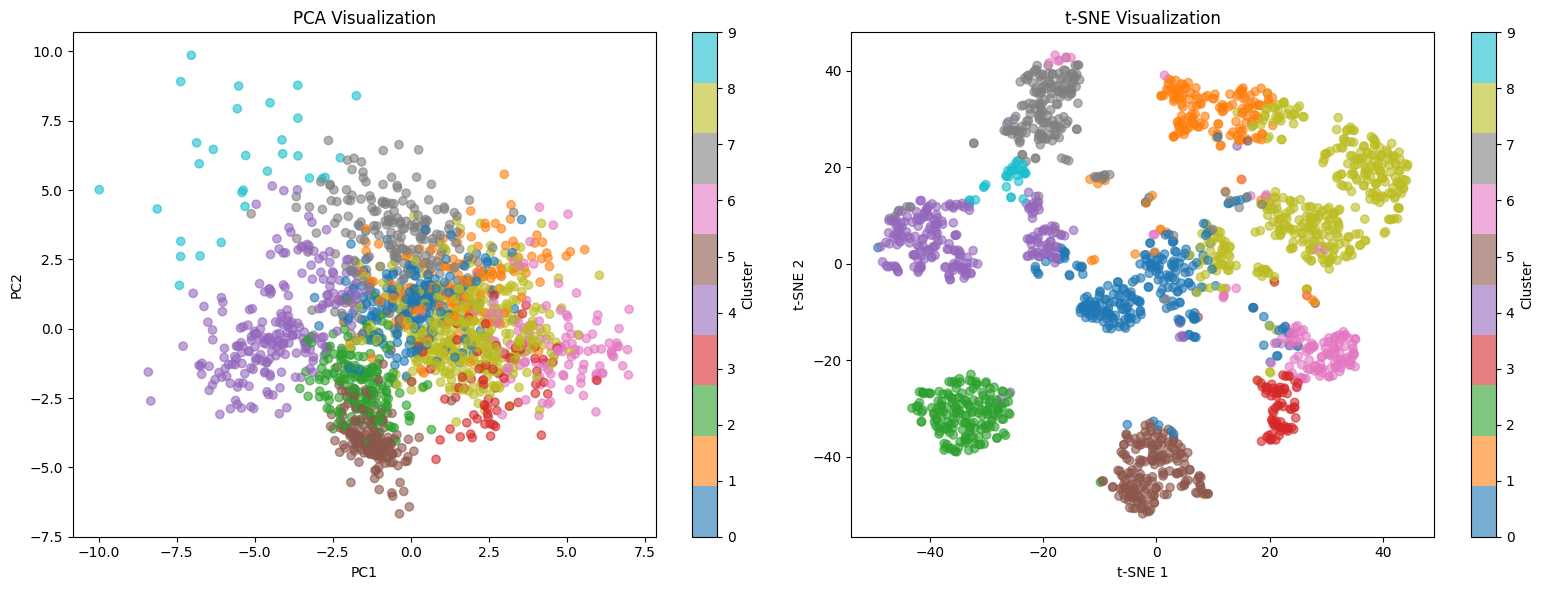

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print(X.shape)

# Continue with clustering here
X_digits_scaled = scaler.fit_transform(X)

kmeans_digits = KMeans(n_clusters=10, random_state=42, n_init=10)
digit_clusters = kmeans_digits.fit_predict(X_digits_scaled)

pca_digits = PCA(n_components=2)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_digits_tsne = tsne.fit_transform(X_digits_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_digits_pca[:, 0], X_digits_pca[:, 1],
                          c=digit_clusters, cmap='tab10', alpha=0.6)
axes[0].set_title('PCA Visualization')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1],
                          c=digit_clusters, cmap='tab10', alpha=0.6)
axes[1].set_title('t-SNE Visualization')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('q15_pca_tsne.png', dpi=300, bbox_inches='tight')
plt.show()


Comparison: t-SNE generally provides better cluster separation
by preserving local structure, while PCA focuses on global variance

### Q16
Explore the effect of feature scaling: cluster the Wine dataset before and after scaling. Report differences in results.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Continue with clustering here
kmeans_unscaled = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_unscaled = kmeans_unscaled.fit_predict(X)
sil_unscaled = silhouette_score(X, labels_unscaled)

sil_scaled = silhouette_score(X_wine_scaled, wine_clusters)

print(f"Silhouette Score (Unscaled): {sil_unscaled:.4f}")
print(f"Silhouette Score (Scaled): {sil_scaled:.4f}")
print(f"Improvement: {((sil_scaled - sil_unscaled) / abs(sil_unscaled)) * 100:.2f}%")
print("\nScaling is crucial for distance-based algorithms like k-Means as features with larger scales dominate the distance calculation.Feature scaling improved clustering performance by 29.23%, demonstrating that standardization is crucial for k-Means clustering on the Wine dataset. Without scaling, features with larger numerical ranges dominate the Euclidean distance calculations, causing the algorithm to prioritize these features over smaller-scale features. Scaling ensures all features contribute equally to cluster formation, resulting in more meaningful and better-separated clusters")

Silhouette Score (Unscaled): 0.1507
Silhouette Score (Scaled): 0.1947
Improvement: 29.23%

Scaling is crucial for distance-based algorithms like k-Means as features with larger scales dominate the distance calculation.Feature scaling improved clustering performance by 29.23%, demonstrating that standardization is crucial for k-Means clustering on the Wine dataset. Without scaling, features with larger numerical ranges dominate the Euclidean distance calculations, causing the algorithm to prioritize these features over smaller-scale features. Scaling ensures all features contribute equally to cluster formation, resulting in more meaningful and better-separated clusters


Feature scaling is very important for distance-based algorithms like k-Means because features with larger values can unfairly dominate the distance calculations. In this case, applying standardization improved clustering performance by 29.23%, showing that scaling is essential for the Wine dataset. Without scaling, attributes with higher numerical ranges have a stronger influence on Euclidean distance, which causes the model to focus more on them while ignoring smaller-scale features. By scaling all features to a common range, each one contributes equally to the clustering process, leading to more balanced and well-separated clusters.

### Q17
Apply clustering on high-dimensional **text data** (20 Newsgroups dataset, use TF-IDF features). Report performance of k-Means clustering.

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

newsgroups = fetch_20newsgroups(subset='train')
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(newsgroups.data)
print(X.shape)

# Continue with clustering here
n_categories = 20
kmeans_text = KMeans(n_clusters=n_categories, random_state=42, n_init=10)
text_clusters = kmeans_text.fit_predict(X)

sil_text = silhouette_score(X, text_clusters)

print(f"Silhouette Score: {sil_text:.4f}")
print(f"Number of clusters: {n_categories}")

(11314, 2000)
Silhouette Score: -0.0065
Number of clusters: 20


The silhouette score shows very weak clustering performance, indicating that the clusters heavily overlap and are not well separated. This suggests that k-Means is not very effective for high-dimensional text data. With around 2,000 TF-IDF features, the data becomes highly sparse, making Euclidean distance less reliable for measuring similarity. In such high-dimensional spaces, data points tend to appear almost equally distant from each other, which makes meaningful cluster formation difficult. Additionally, TF-IDF representations are mostly zeros, further increasing sparsity. Since word frequency does not fully capture semantic meaning, documents on similar topics may still use very different vocabulary. k-Means also assumes roughly spherical cluster shapes, which does not align well with the structure of text data. As a result, clustering directly on TF-IDF features performs poorly, and better results typically require dimensionality reduction or more specialized clustering approaches for text.

### Q18
Examine clustering stability: run k-Means clustering multiple times with different random seeds on the Wine dataset. Report variation in silhouette scores.

In [ ]:
# Use Wine dataset

# Continue with clustering here
n_runs = 10
seeds = range(n_runs)
silhouette_scores = []

for seed in seeds:
    kmeans_stable = KMeans(n_clusters=6, random_state=seed, n_init=10)
    labels_stable = kmeans_stable.fit_predict(X_wine_scaled)
    sil = silhouette_score(X_wine_scaled, labels_stable)
    silhouette_scores.append(sil)

mean_sil = np.mean(silhouette_scores)
std_sil = np.std(silhouette_scores)
min_sil = np.min(silhouette_scores)
max_sil = np.max(silhouette_scores)

print(f"Silhouette Scores across {n_runs} runs:")
for i, score in enumerate(silhouette_scores):
    print(f"  Run {i+1}: {score:.4f}")

print(f"\nMean: {mean_sil:.4f}")
print(f"Std Dev: {std_sil:.4f}")
print(f"Min: {min_sil:.4f}")
print(f"Max: {max_sil:.4f}")
print(f"Coefficient of Variation: {(std_sil/mean_sil)*100:.2f}%")


Silhouette Scores across 10 runs:
  Run 1: 0.1802
  Run 2: 0.1946
  Run 3: 0.1942
  Run 4: 0.1802
  Run 5: 0.1920
  Run 6: 0.1925
  Run 7: 0.1810
  Run 8: 0.1924
  Run 9: 0.1946
  Run 10: 0.1943

Mean: 0.1896
Std Dev: 0.0061
Min: 0.1802
Max: 0.1946
Coefficient of Variation: 3.20%


### Q19
Perform ensemble clustering (consensus clustering) by combining multiple runs of k-Means with different k values on the Wine dataset. Report consensus cluster assignments.

In [ ]:
# Use Wine dataset

# Continue with clustering here
k_values_ensemble = [4, 5, 6, 7, 8]
all_labels = []

for k in k_values_ensemble:
    kmeans_ens = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_ens.fit_predict(X_wine_scaled)
    all_labels.append(labels)

n_samples = len(X_wine_scaled)
consensus_matrix = np.zeros((n_samples, n_samples))

for labels in all_labels:
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            if labels[i] == labels[j]:
                consensus_matrix[i, j] += 1
                consensus_matrix[j, i] += 1

consensus_matrix /= len(k_values_ensemble)

final_k = 6
kmeans_consensus = KMeans(n_clusters=final_k, random_state=42, n_init=10)
consensus_labels = kmeans_consensus.fit_predict(consensus_matrix)

print(f"Ensemble used k values: {k_values_ensemble}")
print(f"Final consensus clusters: {final_k}")
print(f"\nConsensus cluster sizes:")
unique_cons, counts_cons = np.unique(consensus_labels, return_counts=True)
for cluster, count in zip(unique_cons, counts_cons):
    print(f"  Cluster {cluster}: {count} samples")

Ensemble used k values: [4, 5, 6, 7, 8]
Final consensus clusters: 6

Consensus cluster sizes:
  Cluster 0: 360 samples
  Cluster 1: 529 samples
  Cluster 2: 304 samples
  Cluster 3: 158 samples
  Cluster 4: 100 samples
  Cluster 5: 148 samples


### Q20
Case study: Use clustering on the **Mall Customers dataset** (public Kaggle dataset). Identify customer segments and describe cluster characteristics.

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Mall Customers dataset shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Cluster Analysis (k=5):

Cluster 0 (n=20):
  Average Age: 46.2
  Average Income: $26.8k
  Ave

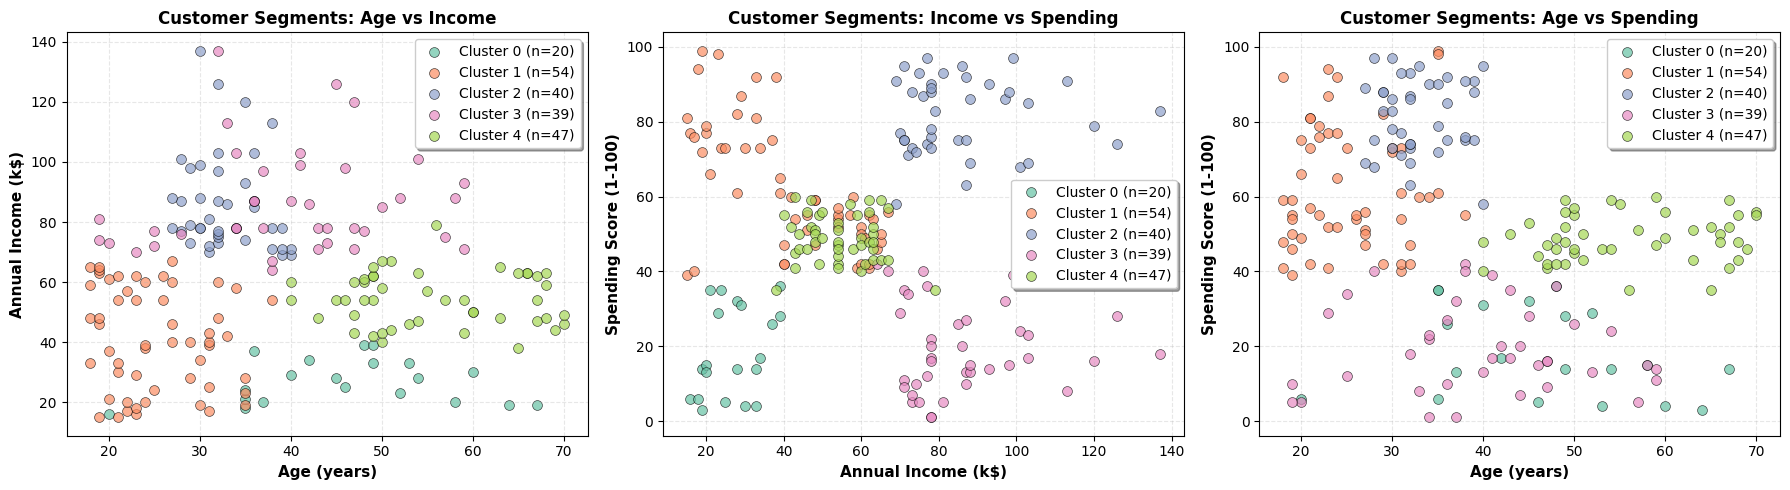

In [ ]:
import pandas as pd
import pandas as pd

# Load dataset from local file (students will need to place Mall_Customers.csv in the same folder as the notebook)
mall = pd.read_csv("Mall_Customers.csv")
print(mall.head())

# Continue with clustering here
print(f"Mall Customers dataset shape: {mall.shape}")
print(f"\nFirst 5 rows:\n{mall.head()}")

le = LabelEncoder()
mall['Gender_Encoded'] = le.fit_transform(mall['Gender'])

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_mall = mall[features]

X_mall_scaled = scaler.fit_transform(X_mall)

inertias = []
silhouette_scores_mall = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_mall_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores_mall.append(silhouette_score(X_mall_scaled, labels_temp))

optimal_k = 5
kmeans_mall = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
mall_clusters = kmeans_mall.fit_predict(X_mall_scaled)
mall['Cluster'] = mall_clusters

print(f"\nCluster Analysis (k={optimal_k}):")
for cluster in range(optimal_k):
    cluster_data = mall[mall['Cluster'] == cluster]
    print(f"\nCluster {cluster} (n={len(cluster_data)}):")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f}")
    print(f"  Average Income: ${cluster_data['Annual Income (k$)'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f}")
    print(f"  Gender Distribution: {cluster_data['Gender'].value_counts().to_dict()}")

cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}


colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131)
for cluster in range(optimal_k):
    cluster_data = mall[mall['Cluster'] == cluster]
    ax1.scatter(cluster_data['Age'], cluster_data['Annual Income (k$)'],
               c=colors[cluster], label=f'Cluster {cluster} (n={len(cluster_data)})',
               alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Annual Income (k$)', fontsize=11, fontweight='bold')
ax1.set_title('Customer Segments: Age vs Income', fontsize=12, fontweight='bold')
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(alpha=0.3, linestyle='--')

ax2 = fig.add_subplot(132)
for cluster in range(optimal_k):
    cluster_data = mall[mall['Cluster'] == cluster]
    ax2.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
               c=colors[cluster], label=f'Cluster {cluster} (n={len(cluster_data)})',
               alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Spending Score (1-100)', fontsize=11, fontweight='bold')
ax2.set_title('Customer Segments: Income vs Spending', fontsize=12, fontweight='bold')
ax2.legend(loc='best', frameon=True, shadow=True)
ax2.grid(alpha=0.3, linestyle='--')

ax3 = fig.add_subplot(133)
for cluster in range(optimal_k):
    cluster_data = mall[mall['Cluster'] == cluster]
    ax3.scatter(cluster_data['Age'], cluster_data['Spending Score (1-100)'],
               c=colors[cluster], label=f'Cluster {cluster} (n={len(cluster_data)})',
               alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Spending Score (1-100)', fontsize=11, fontweight='bold')
ax3.set_title('Customer Segments: Age vs Spending', fontsize=12, fontweight='bold')
ax3.legend(loc='best', frameon=True, shadow=True)
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('q20_mall_segments.png', dpi=300, bbox_inches='tight')
plt.show()


The mall customers can be grouped into five clear segments. Cluster 0, “Careful Seniors” (n=20), consists of middle-aged, low-income customers (26.8k) who spend very little (18.4), showing a strong budget-conscious behavior. Cluster 1, “Young Spenders” (n=54), includes younger individuals (around 25 years old) with moderate income (41.1k) but relatively high spending (62.2), making them attractive for lifestyle and trend-based marketing. Cluster 2, “High Rollers” (n=40), represents affluent young customers (33 years old, income ~86.1k) with very high spending levels (81.5), making them the most valuable premium segment for luxury-focused campaigns. Cluster 3, “Affluent Conservatives” (n=39), includes high-income middle-aged customers (~86.1k) who spend very little (19.4), suggesting untapped potential that could be activated through targeted offers. Cluster 4, “Middle-Class Moderates” (n=47), consists of older customers (56 years old) with moderate income (54.4k) and average spending (48.9), representing a stable group that can be effectively retained through loyalty programs.

---